<a href="https://colab.research.google.com/github/kalyani14-rpr/Agenticbuy/blob/main/cyclone_main_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib numpy pandas

Saving Screenshot 2026-09-25 063642.png to Screenshot 2026-09-25 063642.png
Image uploaded successfully!
Image size: (386, 384, 3)


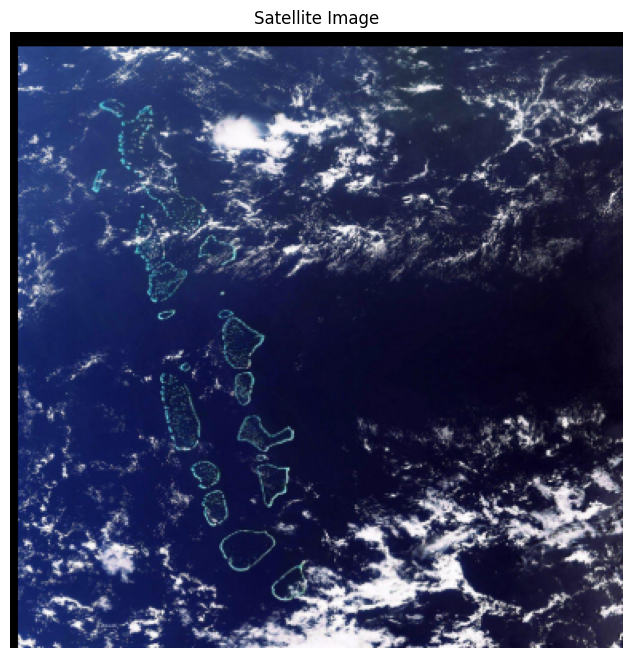

In [2]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image uploaded successfully!")
print("Image size:", image_rgb.shape)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Satellite Image")
plt.show()

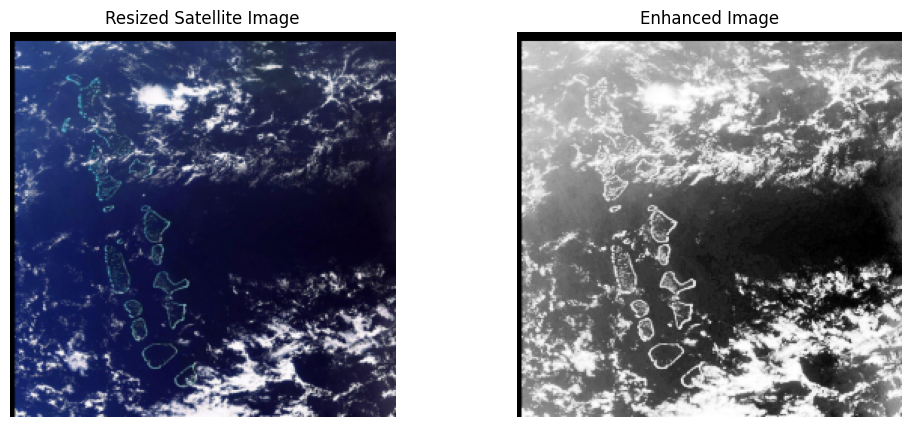

In [3]:
# Resize image
image_resized = cv2.resize(image_rgb, (256, 256))

# Convert to grayscale
gray = cv2.cvtColor(image_resized, cv2.COLOR_RGB2GRAY)

# Improve contrast
enhanced = cv2.equalizeHist(gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title("Resized Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced Image")
plt.axis("off")

plt.show()

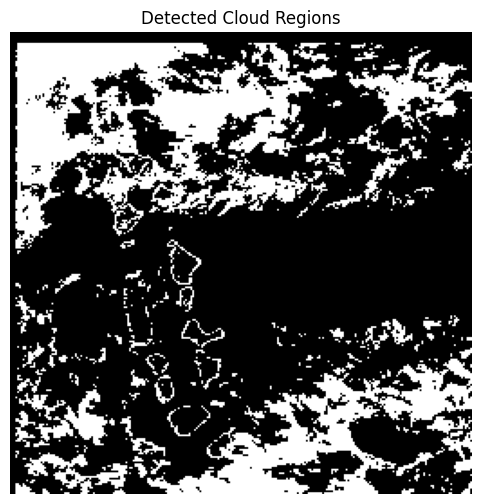

In [4]:
# Threshold bright cloud regions
_, cloud_mask = cv2.threshold(
    enhanced,
    180,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(8, 6))
plt.imshow(cloud_mask, cmap="gray")
plt.title("Detected Cloud Regions")
plt.axis("off")
plt.show()

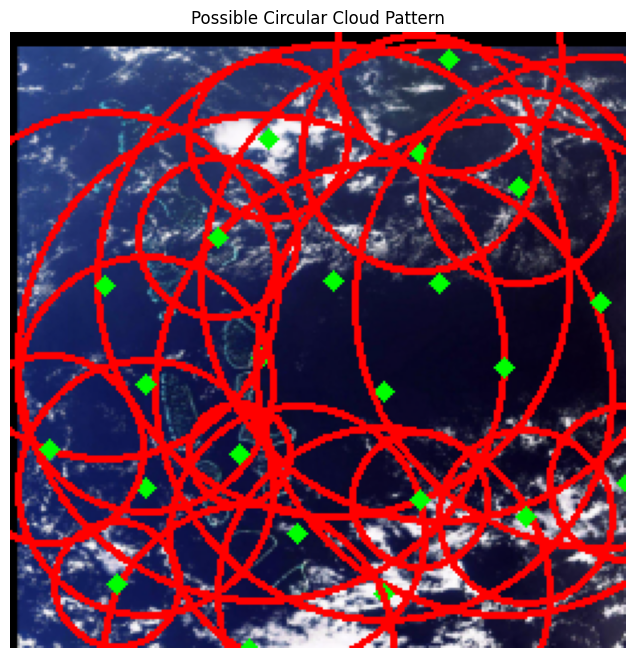

Possible circular cloud pattern detected.


In [5]:
blurred = cv2.GaussianBlur(enhanced, (9, 9), 2)

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=120
)

result = image_resized.copy()

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")

    for x, y, r in circles:
        cv2.circle(result, (x, y), r, (255, 0, 0), 2)
        cv2.circle(result, (x, y), 2, (0, 255, 0), 3)

plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title("Possible Circular Cloud Pattern")
plt.axis("off")
plt.show()

if circles is not None:
    print("Possible circular cloud pattern detected.")
else:
    print("No clear circular cloud pattern detected.")

In [6]:
print("=" * 45)
print("      CYCLONE SATELLITE IMAGE ANALYSIS")
print("=" * 45)

if circles is not None:
    print("Cyclone-like Pattern : DETECTED")
    print("Pattern Type         : Possible Tropical Cyclone")
    print("Status               : Requires AI/ML verification")
else:
    print("Cyclone-like Pattern : NOT CLEARLY DETECTED")
    print("Pattern Type         : Uncertain")
    print("Status               : Requires AI/ML verification")

print("=" * 45)

      CYCLONE SATELLITE IMAGE ANALYSIS
Cyclone-like Pattern : DETECTED
Pattern Type         : Possible Tropical Cyclone
Status               : Requires AI/ML verification


In [8]:
print("=" * 45)
print("      CYCLONE SATELLITE IMAGE ANALYSIS")
print("=" * 45)

if circles is not None:
    print("Cyclone-like Pattern : DETECTED")
    print("Pattern Type         : Possible Tropical Cyclone")
    print("Status               : Requires AI/ML verification")
else:
    print("Cyclone-like Pattern : NOT CLEARLY DETECTED")
    print("Pattern Type         : Uncertain")
    print("Status               : Requires AI/ML verification")

print("=" * 45)

      CYCLONE SATELLITE IMAGE ANALYSIS
Cyclone-like Pattern : DETECTED
Pattern Type         : Possible Tropical Cyclone
Status               : Requires AI/ML verification


In [9]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully!")

Mounted at /content/drive
Google Drive connected successfully!


In [10]:
import os

dataset_path = "/content/cyclone_dataset"

os.makedirs(dataset_path + "/cyclone", exist_ok=True)
os.makedirs(dataset_path + "/no_cyclone", exist_ok=True)

print("Folders created successfully!")
print(dataset_path)

Folders created successfully!
/content/cyclone_dataset


In [11]:
import os

# Create main dataset folder
dataset_path = "/content/cyclone_dataset"

# Create two classes
cyclone_path = os.path.join(dataset_path, "cyclone")
no_cyclone_path = os.path.join(dataset_path, "no_cyclone")

os.makedirs(cyclone_path, exist_ok=True)
os.makedirs(no_cyclone_path, exist_ok=True)

print("Folders created successfully!")
print()
print("Dataset location:", dataset_path)
print()
print("Folder 1:", cyclone_path)
print("Folder 2:", no_cyclone_path)

Folders created successfully!

Dataset location: /content/cyclone_dataset

Folder 1: /content/cyclone_dataset/cyclone
Folder 2: /content/cyclone_dataset/no_cyclone


In [13]:
from google.colab import files
import os
import shutil

print("Upload CYCLONE satellite images")
uploaded = files.upload()

for filename in uploaded.keys():
    source = filename
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(source, destination)

print("\nCyclone images uploaded successfully!")

Upload CYCLONE satellite images


Saving Screenshot 2026-09-25 063642.png to Screenshot 2026-09-25 063642 (1).png

Cyclone images uploaded successfully!


In [14]:
from google.colab import files
import os
import shutil

print("Upload NON-CYCLONE satellite images")
uploaded = files.upload()

for filename in uploaded.keys():
    source = filename
    destination = os.path.join(
        "/content/cyclone_dataset/no_cyclone",
        filename
    )
    shutil.move(source, destination)

print("\nNo-cyclone images uploaded successfully!")

Upload NON-CYCLONE satellite images


Saving Screenshot 2026-09-25 072156.png to Screenshot 2026-09-25 072156.png

No-cyclone images uploaded successfully!


In [15]:
import os

cyclone_files = os.listdir("/content/cyclone_dataset/cyclone")
no_cyclone_files = os.listdir("/content/cyclone_dataset/no_cyclone")

print("Cyclone images    :", len(cyclone_files))
print("No-cyclone images :", len(no_cyclone_files))

Cyclone images    : 1
No-cyclone images : 1


In [17]:
import os

cyclone_files = os.listdir("/content/cyclone_dataset/cyclone")
no_cyclone_files = os.listdir("/content/cyclone_dataset/no_cyclone")

print("Cyclone images    :", len(cyclone_files))
print("No-cyclone images :", len(no_cyclone_files))

Cyclone images    : 1
No-cyclone images : 1


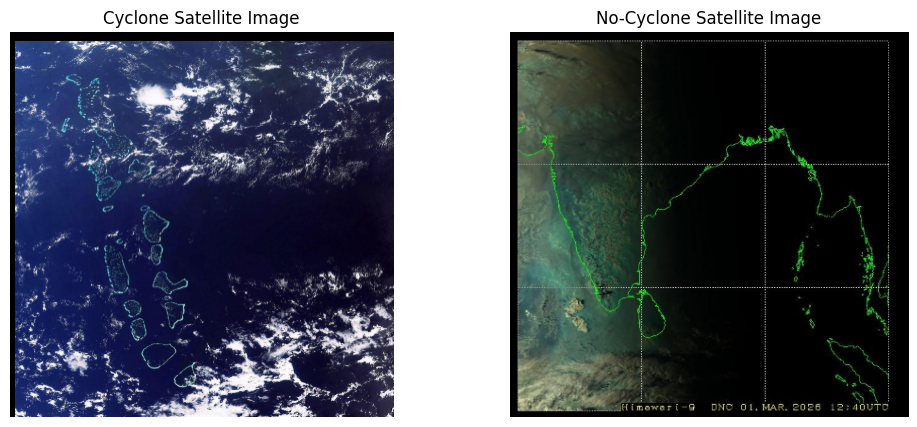

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Get the image filenames
cyclone_file = cyclone_files[0]
no_cyclone_file = no_cyclone_files[0]

# Full paths
cyclone_path = os.path.join(
    "/content/cyclone_dataset/cyclone",
    cyclone_file
)

no_cyclone_path = os.path.join(
    "/content/cyclone_dataset/no_cyclone",
    no_cyclone_file
)

# Open images
cyclone_image = Image.open(cyclone_path)
no_cyclone_image = Image.open(no_cyclone_path)

# Display images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cyclone_image)
plt.title("Cyclone Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(no_cyclone_image)
plt.title("No-Cyclone Satellite Image")
plt.axis("off")

plt.show()

In [20]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 063747.png to Screenshot 2026-09-25 063747.png
Cyclone images added successfully!
Total cyclone images: 2


In [21]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 063809.png to Screenshot 2026-09-25 063809.png
Cyclone images added successfully!
Total cyclone images: 3


In [22]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 063827.png to Screenshot 2026-09-25 063827.png
Cyclone images added successfully!
Total cyclone images: 4


In [23]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073333.png to Screenshot 2026-09-25 073333.png
Cyclone images added successfully!
Total cyclone images: 5


In [24]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073353.png to Screenshot 2026-09-25 073353.png
Cyclone images added successfully!
Total cyclone images: 6


In [25]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073412.png to Screenshot 2026-09-25 073412.png
Cyclone images added successfully!
Total cyclone images: 7


In [26]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073610.png to Screenshot 2026-09-25 073610.png
Cyclone images added successfully!
Total cyclone images: 8


In [27]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073621.png to Screenshot 2026-09-25 073621.png
Cyclone images added successfully!
Total cyclone images: 9


In [28]:
from google.colab import files
import os
import shutil

print("Select MORE CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/cyclone",
        filename
    )
    shutil.move(filename, destination)

print("Cyclone images added successfully!")
print(
    "Total cyclone images:",
    len(os.listdir("/content/cyclone_dataset/cyclone"))
)

Select MORE CYCLONE satellite images


Saving Screenshot 2026-09-25 073630.png to Screenshot 2026-09-25 073630.png
Cyclone images added successfully!
Total cyclone images: 10


In [29]:
from google.colab import files
import os
import shutil

print("Select MORE NON-CYCLONE satellite images")

uploaded = files.upload()

for filename in uploaded.keys():
    destination = os.path.join(
        "/content/cyclone_dataset/no_cyclone",
        filename
    )
    shutil.move(filename, destination)

print("No-cyclone images added successfully!")
print(
    "Total no-cyclone images:",
    len(os.listdir("/content/cyclone_dataset/no_cyclone"))
)

Select MORE NON-CYCLONE satellite images


Saving Screenshot 2026-09-25 074057.png to Screenshot 2026-09-25 074057.png
No-cyclone images added successfully!
Total no-cyclone images: 2
